# 04 — Bayesian Smoothing & Recency Penalty

**Goal:** Regularize RDS scores with Bayesian shrinkage and add recency penalties to prevent notification fatigue.

This notebook covers two layers:
- **Bayesian smoothing** — pull noisy scores toward the mean (protects against small-sample luck)
- **Recency penalty** — penalize templates recently sent to the same user (prevents repetition)

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.scoring.bayesian_smoothing import bayesian_smooth, compute_global_mean
from src.recency.recency_penalty import (
    compute_recency_penalty,
    adjust_scores_with_recency,
    explain_recency_adjustment,
)

sns.set_style("whitegrid")

INTERMEDIATE_DIR = os.path.join("..", "data", "intermediate")

print("Ready!")

Ready!


---
## 1. Load Full-Data RDS Scores from Notebook 03

We load the RDS scores computed from all ~88M training rows. No need to reprocess the data.

In [2]:
with open(os.path.join(INTERMEDIATE_DIR, "03_results.json")) as f:
    prev = json.load(f)

reward_rates = prev["reward_rates"]
counts = {k: int(v) for k, v in prev["counts"].items()}
rds_scores = prev["rds_scores"]
total_rows = prev["total_rows"]
templates = sorted(rds_scores.keys())

print(f"Loaded RDS scores from full data ({total_rows:,} rows)")
for t in templates:
    print(f"  Template {t}: RDS = {rds_scores[t]:+.6f}, count = {counts[t]:,}")

Loaded RDS scores from full data (87,665,839 rows)
  Template A: RDS = +0.124448, count = 3,472,696
  Template B: RDS = -0.006922, count = 9,059,625
  Template C: RDS = -0.000000, count = 2,523,858
  Template D: RDS = -0.004490, count = 9,054,749
  Template E: RDS = -0.005924, count = 9,060,589
  Template F: RDS = -0.006546, count = 9,057,400
  Template G: RDS = -0.003868, count = 9,058,068
  Template H: RDS = -0.006920, count = 9,124,283
  Template J: RDS = -0.005097, count = 9,062,686
  Template K: RDS = -0.004072, count = 9,129,646
  Template L: RDS = -0.003776, count = 9,062,239


---
## 2. The Noise Problem

Not all RDS scores are equally trustworthy. A template sent 10 million times has a very reliable score. A template sent only 50 times? Its score could be wildly off just by luck.

Let's see the count spread:

In [3]:
count_df = pd.DataFrame({
    "template": templates,
    "rds": [rds_scores[t] for t in templates],
    "count": [counts[t] for t in templates],
})

print("Template observation counts:\n")
print(count_df.sort_values("count").to_string(index=False))
print(f"\nRange: {count_df['count'].min():,} – {count_df['count'].max():,}")
print(f"Templates with few counts have noisier RDS — we shouldn't trust them as much.")

Template observation counts:

template           rds   count
       C -1.734790e-17 2523858
       A  1.244477e-01 3472696
       D -4.490293e-03 9054749
       F -6.545855e-03 9057400
       G -3.868039e-03 9058068
       B -6.922066e-03 9059625
       E -5.923821e-03 9060589
       L -3.776154e-03 9062239
       J -5.097204e-03 9062686
       H -6.920274e-03 9124283
       K -4.072427e-03 9129646

Range: 2,523,858 – 9,129,646
Templates with few counts have noisier RDS — we shouldn't trust them as much.


---
## 3. Bayesian Shrinkage

The fix: **pull every score toward the global average**. Templates with lots of data barely move. Templates with little data get pulled strongly.

$$\text{smoothed}(a) = \frac{n_a \times \text{RDS}(a) + \kappa \times \mu}{n_a + \kappa}$$

Where:
- $n_a$ = number of observations for template $a$
- $\kappa$ = shrinkage strength (hyperparameter)
- $\mu$ = global weighted mean of all RDS scores

**Intuition:**
- If $n_a \gg \kappa$: data dominates → score barely changes
- If $n_a \ll \kappa$: prior dominates → score pulled to mean
- When $n_a = \kappa$: score is halfway between data and prior

In [4]:
kappa = 1000
smoothed_scores = bayesian_smooth(rds_scores, counts, kappa)

[bayesian_smoothing] Global weighted mean RDS: +0.000001
[bayesian_smoothing] Kappa (shrinkage strength): 1000
  Template A: raw=+0.124448 → smoothed=+0.124412 (n=3,472,696, ≈same)
  Template B: raw=-0.006922 → smoothed=-0.006921 (n=9,059,625, ≈same)
  Template C: raw=-0.000000 → smoothed=+0.000000 (n=2,523,858, ≈same)
  Template D: raw=-0.004490 → smoothed=-0.004490 (n=9,054,749, ≈same)
  Template E: raw=-0.005924 → smoothed=-0.005923 (n=9,060,589, ≈same)
  Template F: raw=-0.006546 → smoothed=-0.006545 (n=9,057,400, ≈same)
  Template G: raw=-0.003868 → smoothed=-0.003868 (n=9,058,068, ≈same)
  Template H: raw=-0.006920 → smoothed=-0.006920 (n=9,124,283, ≈same)
  Template J: raw=-0.005097 → smoothed=-0.005097 (n=9,062,686, ≈same)
  Template K: raw=-0.004072 → smoothed=-0.004072 (n=9,129,646, ≈same)
  Template L: raw=-0.003776 → smoothed=-0.003776 (n=9,062,239, ≈same)


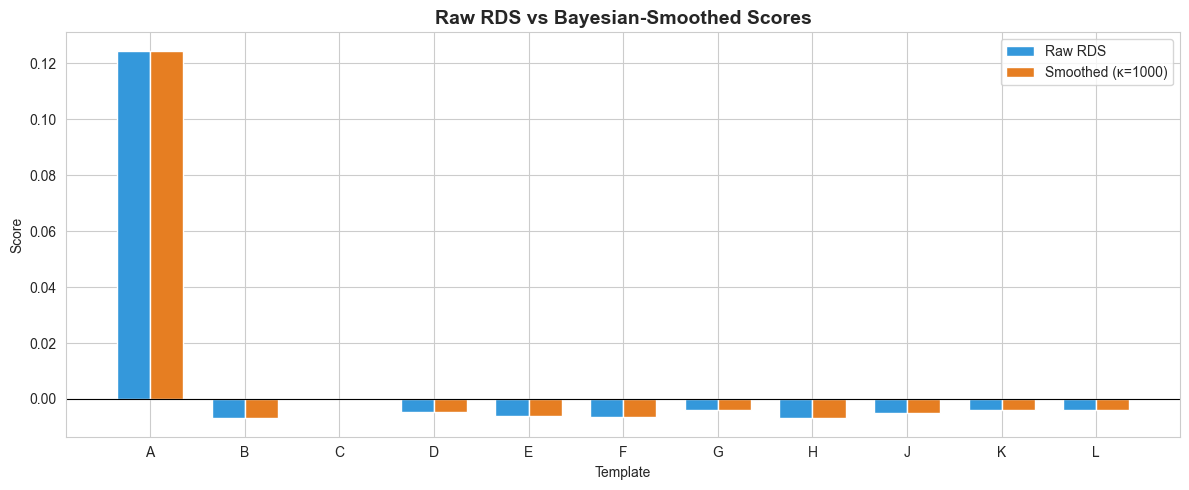

Templates most affected by smoothing (biggest shift):
  A: shifted by 0.000036  (n=3,472,696)
  B: shifted by 0.000001  (n=9,059,625)
  H: shifted by 0.000001  (n=9,124,283)
  F: shifted by 0.000001  (n=9,057,400)
  E: shifted by 0.000001  (n=9,060,589)


In [5]:
# Before vs After chart
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(templates))
width = 0.35

raw_vals = [rds_scores[t] for t in templates]
smooth_vals = [smoothed_scores[t] for t in templates]

ax.bar(x - width/2, raw_vals, width, label="Raw RDS", color="#3498db", edgecolor="white")
ax.bar(x + width/2, smooth_vals, width, label=f"Smoothed (κ={kappa})", color="#e67e22", edgecolor="white")
ax.axhline(y=0, color="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(templates)
ax.set_title("Raw RDS vs Bayesian-Smoothed Scores", fontsize=14, fontweight="bold")
ax.set_xlabel("Template")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

print("Templates most affected by smoothing (biggest shift):")
shifts = [(t, abs(smoothed_scores[t] - rds_scores[t]), counts[t]) for t in templates]
shifts.sort(key=lambda x: x[1], reverse=True)
for t, shift, n in shifts[:5]:
    print(f"  {t}: shifted by {shift:.6f}  (n={n:,})")

---
## 4. Effect of κ — How Much Shrinkage?

Higher κ = more conservative (scores pulled more strongly toward the mean).

In [6]:
kappa_values = [100, 500, 1000, 5000]

results = {}
for k in kappa_values:
    results[k] = bayesian_smooth(rds_scores, counts, k)

# Table
print(f"\n{'Template':<10}", end="")
print(f"{'Raw RDS':>12}", end="")
for k in kappa_values:
    print(f"{'κ='+str(k):>12}", end="")
print()
print("-" * (10 + 12 + 12 * len(kappa_values)))

for t in templates:
    print(f"{t:<10}", end="")
    print(f"{rds_scores[t]:>+12.6f}", end="")
    for k in kappa_values:
        print(f"{results[k][t]:>+12.6f}", end="")
    print()

[bayesian_smoothing] Global weighted mean RDS: +0.000001
[bayesian_smoothing] Kappa (shrinkage strength): 100
  Template A: raw=+0.124448 → smoothed=+0.124444 (n=3,472,696, ≈same)
  Template B: raw=-0.006922 → smoothed=-0.006922 (n=9,059,625, ≈same)
  Template C: raw=-0.000000 → smoothed=+0.000000 (n=2,523,858, ≈same)
  Template D: raw=-0.004490 → smoothed=-0.004490 (n=9,054,749, ≈same)
  Template E: raw=-0.005924 → smoothed=-0.005924 (n=9,060,589, ≈same)
  Template F: raw=-0.006546 → smoothed=-0.006546 (n=9,057,400, ≈same)
  Template G: raw=-0.003868 → smoothed=-0.003868 (n=9,058,068, ≈same)
  Template H: raw=-0.006920 → smoothed=-0.006920 (n=9,124,283, ≈same)
  Template J: raw=-0.005097 → smoothed=-0.005097 (n=9,062,686, ≈same)
  Template K: raw=-0.004072 → smoothed=-0.004072 (n=9,129,646, ≈same)
  Template L: raw=-0.003776 → smoothed=-0.003776 (n=9,062,239, ≈same)
[bayesian_smoothing] Global weighted mean RDS: +0.000001
[bayesian_smoothing] Kappa (shrinkage strength): 500
  Template

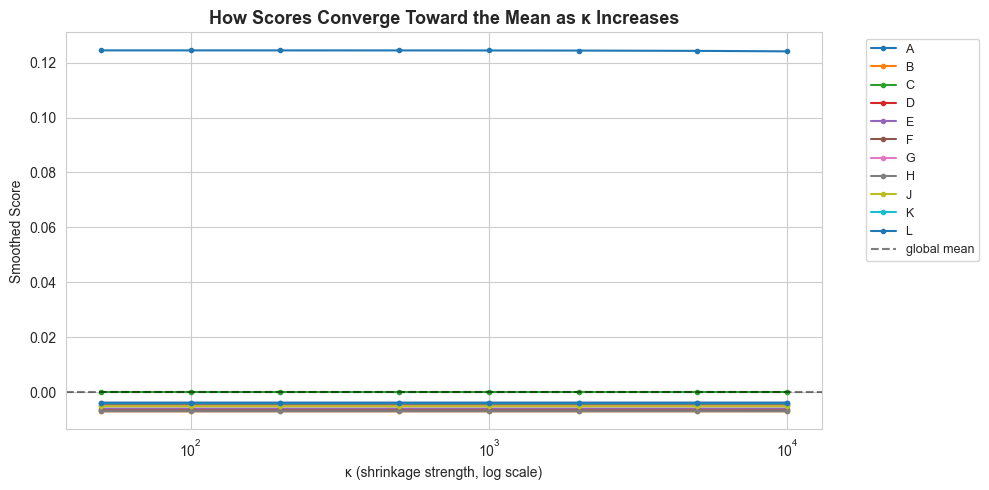

In [7]:
# Line chart showing how scores converge as kappa increases
fig, ax = plt.subplots(figsize=(10, 5))

kappas_fine = [50, 100, 200, 500, 1000, 2000, 5000, 10000]
global_mean = compute_global_mean(rds_scores, counts)

for t in templates:
    scores_over_k = []
    for k in kappas_fine:
        s = (counts[t] * rds_scores[t] + k * global_mean) / (counts[t] + k)
        scores_over_k.append(s)
    ax.plot(kappas_fine, scores_over_k, marker="o", markersize=3, label=t)

ax.axhline(y=global_mean, color="black", linestyle="--", alpha=0.5, label="global mean")
ax.set_xscale("log")
ax.set_xlabel("κ (shrinkage strength, log scale)")
ax.set_ylabel("Smoothed Score")
ax.set_title("How Scores Converge Toward the Mean as κ Increases", fontsize=13, fontweight="bold")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Recency Penalty — Concept

Even the best template gets stale if sent repeatedly. The **recency penalty** subtracts a value from a template's score based on how recently it was sent to this user:

$$\text{penalty}(a) = \gamma \times e^{-h \times d}$$

Where:
- $\gamma$ = maximum penalty (when template was just sent, $d = 0$)
- $h$ = decay rate (how fast the penalty fades)
- $d$ = days since template was last sent

The template "recovers" over time — hence the name **Recovering Bandit**.

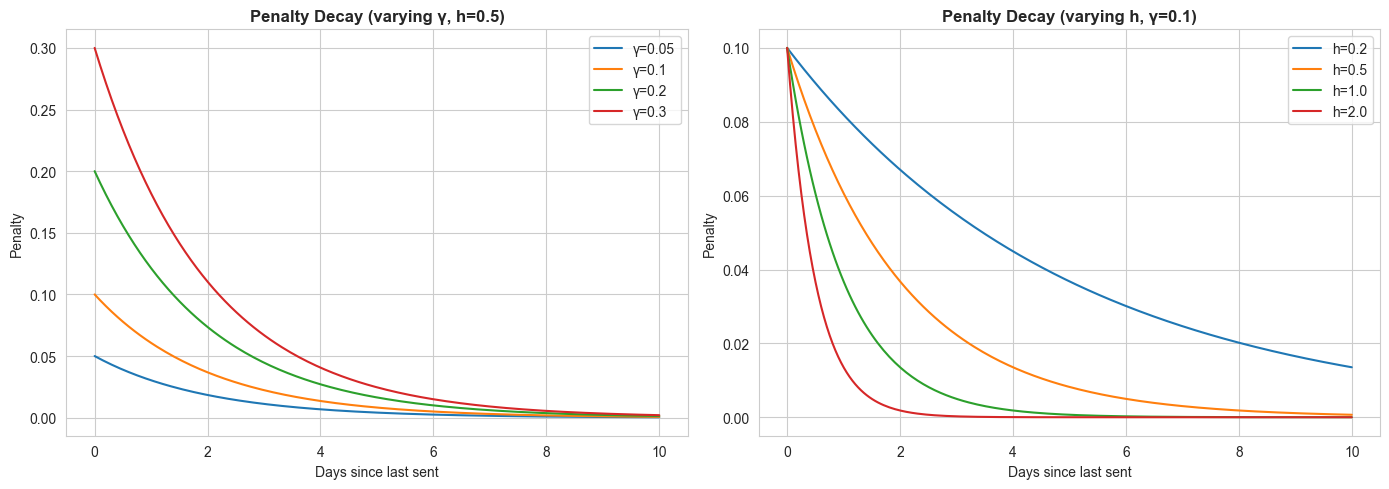

Left: higher γ = stronger maximum penalty (bigger hit right after sending)
Right: higher h = faster decay (penalty fades more quickly)


In [8]:
# Visualize the decay curve
days = np.linspace(0, 10, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: vary gamma
h_fixed = 0.5
for gamma in [0.05, 0.1, 0.2, 0.3]:
    penalty = gamma * np.exp(-h_fixed * days)
    axes[0].plot(days, penalty, label=f"γ={gamma}")
axes[0].set_title(f"Penalty Decay (varying γ, h={h_fixed})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Days since last sent")
axes[0].set_ylabel("Penalty")
axes[0].legend()

# Right: vary h
gamma_fixed = 0.1
for h in [0.2, 0.5, 1.0, 2.0]:
    penalty = gamma_fixed * np.exp(-h * days)
    axes[1].plot(days, penalty, label=f"h={h}")
axes[1].set_title(f"Penalty Decay (varying h, γ={gamma_fixed})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Days since last sent")
axes[1].set_ylabel("Penalty")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Left: higher γ = stronger maximum penalty (bigger hit right after sending)")
print("Right: higher h = faster decay (penalty fades more quickly)")

---
## 6. Worked Example — Recency Adjustment

Let's pick a few templates and simulate a user history to see how scores change.

In [9]:
gamma = 0.1
h = 0.5

# Use the first 4 templates
demo_templates = templates[:4]
demo_scores = {t: smoothed_scores[t] for t in demo_templates}

print("=" * 55)
print("SCENARIO 1: New user (no history)")
print("Expectation: no penalties, scores unchanged")
print("=" * 55)
adjusted = explain_recency_adjustment(demo_scores, [], gamma, h)

SCENARIO 1: New user (no history)
Expectation: no penalties, scores unchanged

[recency_penalty] Adjusting scores with γ=0.1, h=0.5
[recency_penalty] User history: []
Template    Raw Score    Penalty   Adjusted Note
-------------------------------------------------------
A           +0.124412   0.000000  +0.124412 never sent
B           -0.006921   0.000000  -0.006921 never sent
C           +0.000000   0.000000  +0.000000 never sent
D           -0.004490   0.000000  -0.004490 never sent


In [10]:
print("=" * 55)
print(f"SCENARIO 2: Template {demo_templates[0]} sent 0.5 days ago")
print(f"Expectation: {demo_templates[0]} gets penalized, others unchanged")
print("=" * 55)

history = [(demo_templates[0], 0.5)]
adjusted = explain_recency_adjustment(demo_scores, history, gamma, h)

p = compute_recency_penalty(demo_templates[0], history, gamma, h)
print(f"\nPenalty = γ × exp(-h × d) = {gamma} × exp(-{h} × 0.5) = {p:.6f}")

SCENARIO 2: Template A sent 0.5 days ago
Expectation: A gets penalized, others unchanged

[recency_penalty] Adjusting scores with γ=0.1, h=0.5
[recency_penalty] User history: [('A', 0.5)]
Template    Raw Score    Penalty   Adjusted Note
-------------------------------------------------------
A           +0.124412   0.077880  +0.046532 sent 0.5d ago
B           -0.006921   0.000000  -0.006921 never sent
C           +0.000000   0.000000  +0.000000 never sent
D           -0.004490   0.000000  -0.004490 never sent

Penalty = γ × exp(-h × d) = 0.1 × exp(-0.5 × 0.5) = 0.077880


In [11]:
print("=" * 55)
print("SCENARIO 3: Multiple templates in history")
print("=" * 55)

history_multi = [
    (demo_templates[0], 0.3),   # sent very recently
    (demo_templates[1], 2.0),   # sent 2 days ago
    (demo_templates[2], 7.0),   # sent a week ago
]
print(f"History: {history_multi}")
adjusted = explain_recency_adjustment(demo_scores, history_multi, gamma, h)

print(f"\nNotice how penalty decreases with time:")
print(f"  {demo_templates[0]} (0.3d ago): strong penalty")
print(f"  {demo_templates[1]} (2.0d ago): moderate penalty")
print(f"  {demo_templates[2]} (7.0d ago): almost no penalty")
print(f"  {demo_templates[3]}: not in history → zero penalty")

SCENARIO 3: Multiple templates in history
History: [('A', 0.3), ('B', 2.0), ('C', 7.0)]

[recency_penalty] Adjusting scores with γ=0.1, h=0.5
[recency_penalty] User history: [('A', 0.3), ('B', 2.0), ('C', 7.0)]
Template    Raw Score    Penalty   Adjusted Note
-------------------------------------------------------
A           +0.124412   0.086071  +0.038341 sent 0.3d ago
B           -0.006921   0.036788  -0.043709 sent 2.0d ago
C           +0.000000   0.003020  -0.003020 sent 7.0d ago
D           -0.004490   0.000000  -0.004490 never sent

Notice how penalty decreases with time:
  A (0.3d ago): strong penalty
  B (2.0d ago): moderate penalty
  C (7.0d ago): almost no penalty
  D: not in history → zero penalty


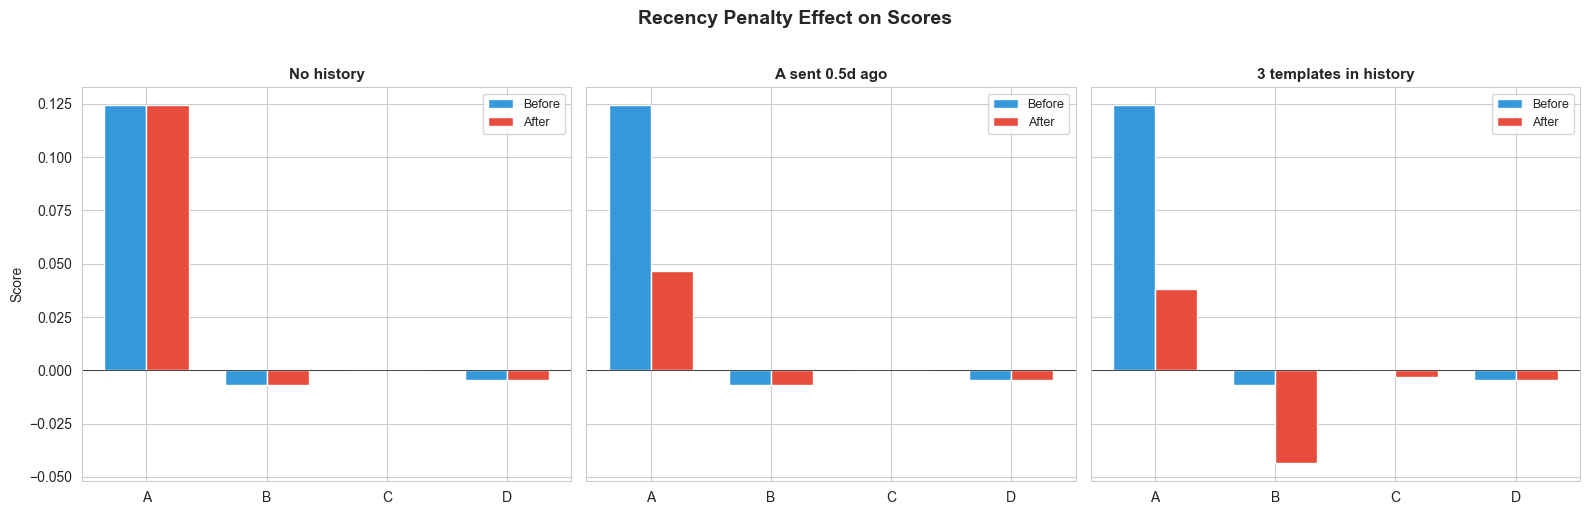

In [12]:
# Visualize the three scenarios
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

scenarios = [
    ("No history", []),
    (f"{demo_templates[0]} sent 0.5d ago", [(demo_templates[0], 0.5)]),
    ("3 templates in history", history_multi),
]

for ax, (title, hist) in zip(axes, scenarios):
    adj = adjust_scores_with_recency(demo_scores, hist, gamma, h)
    
    x_pos = np.arange(len(demo_templates))
    w = 0.35
    
    ax.bar(x_pos - w/2, [demo_scores[t] for t in demo_templates], w,
           label="Before", color="#3498db", edgecolor="white")
    ax.bar(x_pos + w/2, [adj[t] for t in demo_templates], w,
           label="After", color="#e74c3c", edgecolor="white")
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(demo_templates)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Score")
plt.suptitle("Recency Penalty Effect on Scores", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Summary

| Layer | What it does | Key parameter |
|-------|-------------|---------------|
| **Bayesian smoothing** | Pulls noisy scores toward global mean | κ (kappa) — higher = more conservative |
| **Recency penalty** | Penalizes recently-sent templates | γ (magnitude), h (decay rate) |

After these two layers, we have **adjusted scores** for each template, personalized to each user's history. The final step is to convert these scores into a probability distribution for template selection.

**Next notebook:** `05_softmax_selection.ipynb` — use softmax to select templates while balancing exploration and exploitation.

In [13]:
# Save smoothed scores for next notebooks
results_04 = {
    "reward_rates": reward_rates,
    "counts": counts,
    "rds_scores": rds_scores,
    "smoothed_scores": smoothed_scores,
    "total_rows": total_rows,
}

save_path = os.path.join(INTERMEDIATE_DIR, "04_results.json")
with open(save_path, "w") as f:
    json.dump(results_04, f, indent=2)

print(f"✅ Saved to {save_path}")

✅ Saved to ../data/intermediate/04_results.json
